In [1]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np

import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/Collaboration/backup/MPRA_QC_pipeline/QC_analysis/scripts')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


ImportError: cannot import name 'MPRA_data_paths' from 'const' (/home/labs/davidgo/Collaboration/backup/MPRA_QC_pipeline/QC_analysis/scripts/const.py)

# Read Diff vs Active Enrichment results

In [2]:
analysis = 'final_analysis_v6'

diff_vs_active_kegg = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/kegg_raw_output.csv')
diff_vs_active_HPO = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/HPO_raw_output.csv')
diff_vs_active_GAD = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/GAD_disease_raw_output.csv')
diff_vs_active_GO = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/GO_raw_output.csv')

diff_vs_active_HPO = diff_vs_active_HPO.rename(columns={"Pheno": "Term",
                                                        "Enrichment":'FoldChange',
                                                        "Observed (n_entered)":'Observed genes associated with term'})


diff_vs_active_merged = pd.concat([diff_vs_active_kegg[['Term','FoldChange','FDR','Observed genes associated with term']],
                                diff_vs_active_HPO[['Term','FoldChange','FDR','Observed genes associated with term']],  
                                diff_vs_active_GO[['Term','FoldChange','FDR','Observed genes associated with term']],  
                                diff_vs_active_GAD[['Term','FoldChange','FDR','Observed genes associated with term']]], axis=0) 


suffix = " - Homo sapiens (human)"

diff_vs_active_merged = (
    diff_vs_active_merged
    .copy()
    .sort_values("FDR")
    .loc[lambda d: d["FDR"] <= 0.05]
    .assign(
        Term=lambda d: (
            d["Term"]
            .str.replace(suffix, "", regex=False)     # remove suffix
            .str.replace(r".*~", "", regex=True)      # remove everything before "~"
        )
    )
)

diff_vs_active_merged.to_csv("/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/enrichment_analysis_results.tsv",sep='\t',index ='False')

compare_HPO = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/compare/HPO_raw_output.csv')
compare_kegg = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/compare/kegg_raw_output.csv')
compare_GO = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/compare/GO_raw_output.csv')


compare_HPO = compare_HPO.rename(columns={"Pheno": "Term"})



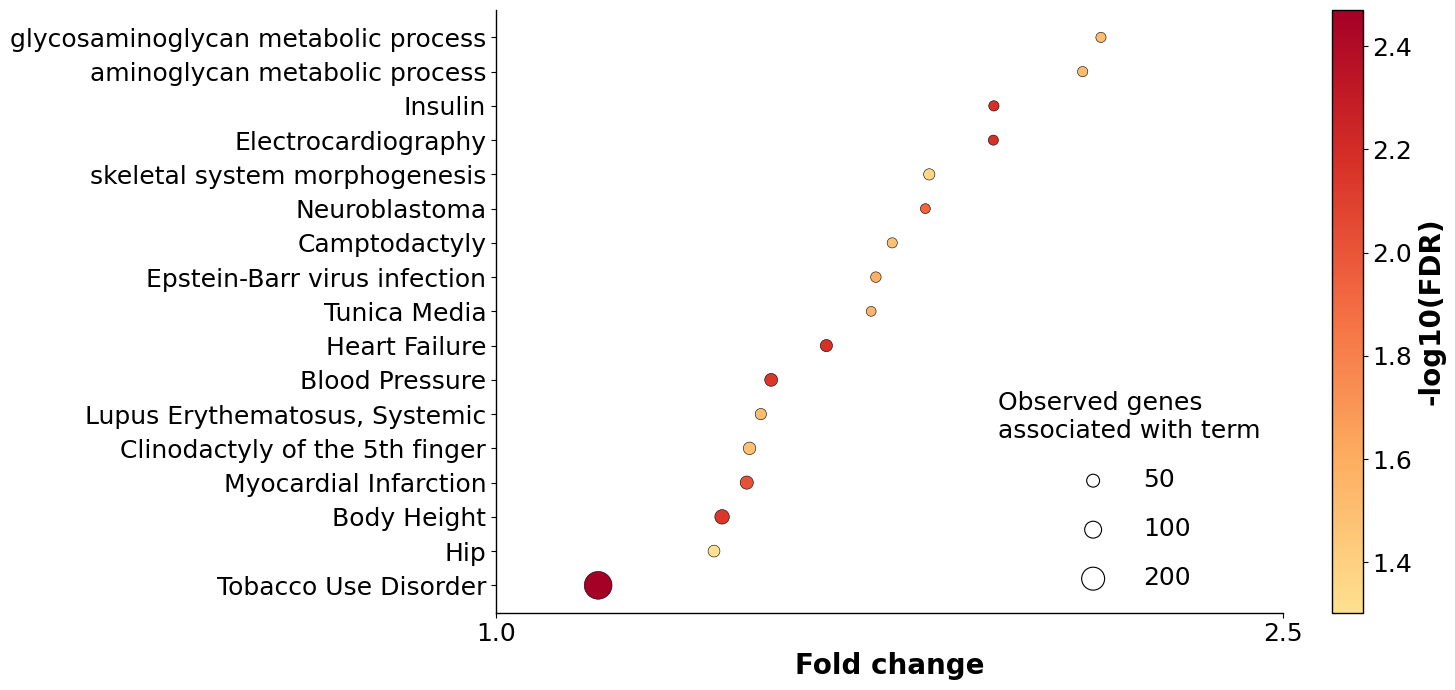

In [19]:
# ---- Copy & clean ----
df = diff_vs_active_merged.copy()
df = df.dropna(subset=["Term", "FoldChange", "FDR", "Observed genes associated with term"])

# log2 fold change

# ---- Choose top N terms by log2FC ----
top_n = 20  # <- change this as you like
plot_df = df.sort_values("FoldChange", ascending=True).head(top_n)

# ---- Dot size: scale by "Observed genes associated with term" ----
sizes_raw = plot_df["Observed genes associated with term"].astype(float)
size_min, size_max = 50, 400
sizes_scaled = size_min + (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min() + 1e-9) * (size_max - size_min)

# ---- Color: hot colormap based on FDR (use -log10 so low FDR = hotter) ----
colors = -np.log10(plot_df["FDR"].astype(float))

fig, ax = plt.subplots(figsize=(3, 0.3 * top_n + 1))

sc = ax.scatter(
    plot_df["FoldChange"],
    plot_df["Term"],
    s=sizes_scaled,
    c=colors,
    cmap=custom_cmap_bolder,      # hot color scheme
    edgecolor="k",
    linewidth=0.4
)

# Axis labels
ax.set_xlabel("Fold change")
ax.set_ylabel("")
ax.set_xlim(1,2.5)

# No grid (per your usual preference)
ax.grid(False)

# Keep your tick simplification
xticks = ax.get_xticks()
ax.set_xticks([xticks[0], xticks[-1]])

const.save_fig(plt, 'MPRA_enrichment_analysis', output_path)


# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(FDR)")

# ---- Size legend (uses the same scaling as sizes_scaled) ----
legend_vals = [50,100,200]
def scale_size(v):
    return size_min + (v - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min() + 1e-9) * (size_max - size_min)

legend_sizes = [scale_size(v) for v in legend_vals]

handles = [
    ax.scatter([], [], s=s, facecolors="none", edgecolors="k", linewidth=0.8)
    for s in legend_sizes
]


size_legend = ax.legend(
    handles,
    [str(v) for v in legend_vals],
    title="Observed genes\nassociated with term",
    loc="lower right",      # adjust as needed
    frameon=False,
    labelspacing=1.0,
    handletextpad=1.0,
)
fig.set_size_inches(15, 0.3 * top_n + 1, forward=True)



const.save_fig(plt, 'MPRA_enrichment_analysis_w_bar', output_path)


plt.tight_layout()
plt.show()


# Read diff vs active enrichment results (ASE)

In [118]:
diff_vs_active_ASE_merged

,Term,FoldChange,FDR,Observed genes associated with term
0,Neuroactive ligand-receptor interaction,1.832349,0.000042,55
0,ion transport,1.300246,0.003580,238
1,regulation of ion transport,1.456601,0.005105,114
1,Hypertrophic cardiomyopathy,1.972603,0.006399,22
2,Calcium signaling pathway,1.541625,0.008563,45
3,Metabolic pathways,1.187778,0.014241,192
4,Meningeal Neoplasms|meningioma,1.683637,0.019482,33
3,myocardial infarct,1.884235,0.019482,25
2,several psychiatric disorders,1.518659,0.019482,49
1,"Birth Weight|Leukemia|Leukemia, Myeloid, Acute...",1.696688,0.019482,33


In [124]:
analysis = 'final_analysis_v8_ASE_final'

diff_vs_active_ASE_kegg = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/kegg_raw_output.csv')
diff_vs_active_ASE_HPO = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/HPO_raw_output.csv')
diff_vs_active_ASE_GAD = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/GAD_disease_raw_output.csv')
diff_vs_active_ASE_GO = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/enrichment/{analysis}/diff_vs_active/GO_raw_output.csv')

diff_vs_active_ASE_HPO = diff_vs_active_ASE_HPO.rename(columns={"Pheno": "Term",
                                                        "Enrichment":'FoldChange',
                                                        "Observed (n_entered)":'Observed genes associated with term'})


diff_vs_active_ASE_merged = pd.concat([diff_vs_active_ASE_kegg[['Term','FoldChange','FDR','Observed genes associated with term']],
                                diff_vs_active_ASE_HPO[['Term','FoldChange','FDR','Observed genes associated with term']],  
                                diff_vs_active_ASE_GO[['Term','FoldChange','FDR','Observed genes associated with term']],  
                                diff_vs_active_ASE_GAD[['Term','FoldChange','FDR','Observed genes associated with term']]], axis=0) 


suffix = " - Homo sapiens (human)"  

diff_vs_active_ASE_merged = (
    diff_vs_active_ASE_merged
    .copy()
    .sort_values("FDR")
    .loc[lambda d: d["FDR"] <= 0.05]
    .assign(
        Term=lambda d: (
            d["Term"]
            .str.replace(suffix, "", regex=False)     # remove suffix
            .str.replace(r".*~", "", regex=True)      # remove everything before "~"
        )
    )
)


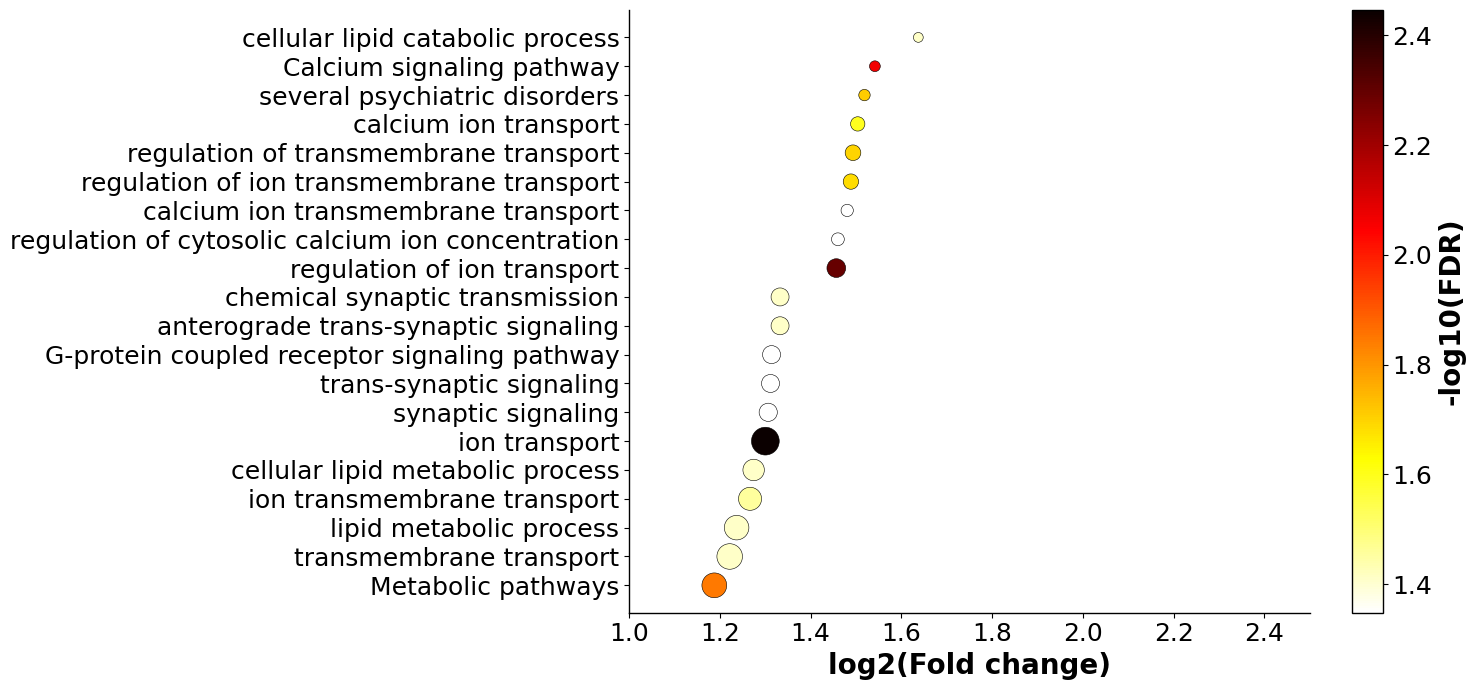

In [126]:
# ---- Copy & clean ----
df = diff_vs_active_ASE_merged.copy()
df = df.dropna(subset=["Term", "FoldChange", "FDR", "Observed genes associated with term"])

# log2 fold change

# ---- Choose top N terms by log2FC ----
top_n = 20  # <- change this as you like
plot_df = df.sort_values("FoldChange", ascending=True).head(top_n)

# ---- Dot size: scale by "Observed genes associated with term" ----
sizes_raw = plot_df["Observed genes associated with term"].astype(float)
size_min, size_max = 50, 400
sizes_scaled = size_min + (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min() + 1e-9) * (size_max - size_min)

# ---- Color: hot colormap based on FDR (use -log10 so low FDR = hotter) ----
colors = -np.log10(plot_df["FDR"].astype(float))

fig, ax = plt.subplots(figsize=(15, 0.3 * top_n + 1))

sc = ax.scatter(
    plot_df["FoldChange"],
    plot_df["Term"],
    s=sizes_scaled,
    c=colors,
    cmap="hot_r",      # hot color scheme
    edgecolor="k",
    linewidth=0.4
)

# Axis labels
ax.set_xlabel("log2(Fold change)")
ax.set_ylabel("")
ax.set_xlim(1,2.5)

# No grid (per your usual preference)
ax.grid(False)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(FDR)")

plt.tight_layout()
plt.show()


# GAGs pathway

In [7]:
from bioservices import KEGG
k = KEGG()
pathways = ["hsa00532 ", # Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate
            "hsa00534",  #Glycosaminoglycan biosynthesis - heparan sulfate / heparin
            "hsa00533",  #Glycosaminoglycan biosynthesis - keratan sulfate
            "hsa00531"  #Glycosaminoglycan degradation
            ]

all_genes = []

for pid in pathways:
    res = k.get(pid)
    parsed = k.parse(res)
    gene_entries = parsed.get("GENE", {})   # some pathways may lack this section
    
    genes = [v.split(";")[0].strip() for v in gene_entries.values()]
    all_genes.extend(genes)

# Unique list and sorted
kegg_gag_genes = sorted(set(all_genes))

print(kegg_gag_genes)
print(len(kegg_gag_genes), "unique genes")


['ARSB', 'B3GALT6', 'B3GAT3', 'B3GNT2', 'B3GNT7', 'B4GALT1', 'B4GALT2', 'B4GALT3', 'B4GALT4', 'B4GALT7', 'CHPF', 'CHPF2', 'CHST1', 'CHST11', 'CHST12', 'CHST13', 'CHST14', 'CHST15', 'CHST2', 'CHST3', 'CHST4', 'CHST6', 'CHST7', 'CHSY1', 'CHSY3', 'CSGALNACT1', 'CSGALNACT2', 'DSE', 'DSEL', 'EXT1', 'EXT2', 'EXTL1', 'EXTL2', 'EXTL3', 'FUT8', 'GALNS', 'GLB1', 'GLCE', 'GNS', 'GUSB', 'HEXA', 'HEXB', 'HGSNAT', 'HPSE', 'HPSE2', 'HS2ST1', 'HS3ST1', 'HS3ST2', 'HS3ST3A1', 'HS3ST3B1', 'HS3ST5', 'HS6ST1', 'HS6ST2', 'HS6ST3', 'HYAL1', 'HYAL2', 'HYAL3', 'HYAL4', 'IDS', 'IDUA', 'NAGLU', 'NDST1', 'NDST2', 'NDST3', 'NDST4', 'SGSH', 'SPAM1', 'ST3GAL1', 'ST3GAL2', 'ST3GAL3', 'UST', 'XYLT1', 'XYLT2']
73 unique genes


In [ ]:
kegg_gag_genes

In [21]:
#Read human MPRA data

hMPRA_data = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     #usecols=range(0, 34), 
                     header=0)

print('# raw: ',len(hMPRA_data))



/tmp/ipykernel_2513607/1153028802.py:3: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  hMPRA_data = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


# raw:  355898


In [2]:
hybrid_data = pd.read_csv(f"/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Hybrids/human_chimp/ExpLBM/outputs_05Jan2026_humanMPRA_draft1/ExpLBM_polarization_results.tsv", 
                     sep = '\t',
                     header=0)
hybrid_data = hybrid_data[hybrid_data['Gene'].notna()]
hybrid_data['ASE_full'] = hybrid_data['ExpLBM_gene_ase_type']+'_'+hybrid_data['derived']

### Generate hybrids extended data table

In [91]:
hybrid_data.to_csv("/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/hybrids_ASE.tsv",sep='\t')

In [4]:
ASE_hybird_data = hybrid_data[hybrid_data['ExpLBM_gene_ase_type']=='ASE']
print(sum(ASE_hybird_data['derived']=='chimp-derived'))
print(sum(ASE_hybird_data['derived']=='human-derived'))

4152
4463


In [70]:
import pandas as pd
from scipy.stats import fisher_exact

# --- Filter to human-derived ASE only ---
df = hybrid_data.copy()
df = df[df["ASE_full"].eq("ASE_human-derived")]

# Ensure LFC is numeric + drop missing
df["ExpLBM_LFC_human_ref"] = pd.to_numeric(df["ExpLBM_LFC_human_ref"], errors="coerce")
df = df.dropna(subset=["ExpLBM_LFC_human_ref", "Gene"])

# Decide what to do with zeros: exclude (common for up/down tests)
df = df[df["ExpLBM_LFC_human_ref"] != 0]

# --- Define membership and direction ---
kegg_set = set(kegg_gag_genes)

in_kegg = df["Gene"].isin(kegg_set)
up   = df["ExpLBM_LFC_human_ref"] > 0
down = df["ExpLBM_LFC_human_ref"] < 0

# --- Counts ---
a = (in_kegg & up).sum()      # KEGG & up
b = (in_kegg & down).sum()    # KEGG & down
c = (~in_kegg & up).sum()     # not KEGG & up
d = (~in_kegg & down).sum()   # not KEGG & down

table = [[int(a), int(b)],
         [int(c), int(d)]]

print("2x2 table [[KEGG & up, KEGG & down], [notKEGG & up, notKEGG & down]]:")
print(table)

oddsratio, pvalue = fisher_exact(table, alternative="two-sided")
print(f"Fisher's exact: oddsratio={oddsratio:.4g}, p={pvalue:.4g}")


2x2 table [[KEGG & up, KEGG & down], [notKEGG & up, notKEGG & down]]:
[[4, 17], [1786, 2656]]
Fisher's exact: oddsratio=0.3499, p=0.07155


In [71]:
ASE_hybird_data = hybrid_data[hybrid_data['ExpLBM_gene_ase_type']=='ASE']
print(sum(ASE_hybird_data['derived']=='chimp-derived'))
print(sum(ASE_hybird_data['derived']=='human-derived'))


4152
4463


In [28]:
hybrid_data_gags = hybrid_data[hybrid_data['Gene'].isin(kegg_gag_genes)]



In [29]:
hybrid_data_gags.to_csv("hybrid_data_gags.csv", index=False)

In [30]:
hybrid_data_gags['ASE_full'] = hybrid_data_gags['ExpLBM_gene_ase_type']+'_'+hybrid_data_gags['derived']

/tmp/ipykernel_3572531/523235255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hybrid_data_gags['ASE_full'] = hybrid_data_gags['ExpLBM_gene_ase_type']+'_'+hybrid_data_gags['derived']


In [72]:
import pandas as pd
from scipy.stats import mannwhitneyu

# --- Filter to human-derived ASE ---
df = hybrid_data.copy()
df = df[df["ASE_full"].eq("ASE_human-derived")]

# Numeric + clean
df["ExpLBM_LFC_human_ref"] = pd.to_numeric(
    df["ExpLBM_LFC_human_ref"], errors="coerce"
)
df = df.dropna(subset=["ExpLBM_LFC_human_ref", "Gene"])

# KEGG membership
kegg_set = set(kegg_gag_genes)

kegg_vals = df.loc[
    df["Gene"].isin(kegg_set),
    "ExpLBM_LFC_human_ref"
]

non_kegg_vals = df.loc[
    ~df["Gene"].isin(kegg_set),
    "ExpLBM_LFC_human_ref"
]

print(f"KEGG GAG genes: n={len(kegg_vals)}")
print(f"Other genes:    n={len(non_kegg_vals)}")

# --- Mann–Whitney U test ---
# alternative options: "two-sided", "greater", "less"
u_stat, pval = mannwhitneyu(
    kegg_vals,
    non_kegg_vals,
    alternative="two-sided"  # KEGG shifted UP
)

print(f"Mann–Whitney U: U={u_stat:.3g}, p={pval:.3g}")


KEGG GAG genes: n=21
Other genes:    n=4442
Mann–Whitney U: U=3.27e+04, p=0.0179


In [75]:
non_kegg_vals

3        0.341566
11      -0.421930
13      -0.811796
15      -0.377762
18      -0.108905
           ...   
52358    0.740288
52368    0.158772
52372    2.918207
52388    0.342737
52432    0.416215
Name: ExpLBM_LFC_human_ref, Length: 4442, dtype: float64

In [78]:
from scipy.stats import ttest_ind
import pandas as pd

# --- Filter to human-derived ASE ---
df = hybrid_data.copy()
df = df[df["ASE_full"].eq("ASE_human-derived")]

df["ExpLBM_LFC_human_ref"] = pd.to_numeric(
    df["ExpLBM_LFC_human_ref"], errors="coerce"
)
df = df.dropna(subset=["ExpLBM_LFC_human_ref", "Gene"])

kegg_set = set(kegg_gag_genes)

kegg_vals = df.loc[
    df["Gene"].isin(kegg_set),
    "ExpLBM_LFC_human_ref"
]

non_kegg_vals = df.loc[
    ~df["Gene"].isin(kegg_set),
    "ExpLBM_LFC_human_ref"
]

print(f"KEGG GAG genes: n={len(kegg_vals)}")
print(f"Other genes:    n={len(non_kegg_vals)}")

# --- Welch's t-test (unequal variance) ---
t_stat, pval = ttest_ind(
    kegg_vals,
    non_kegg_vals,
    equal_var=False,   # CRITICAL
    alternative="two-sided"
)

print(f"Welch t-test: t={t_stat:.3g}, p={pval:.3g}")

np.mean(abs(non_kegg_vals))


KEGG GAG genes: n=21
Other genes:    n=4442
Welch t-test: t=-3.42, p=0.00261


np.float64(0.9725311005059613)

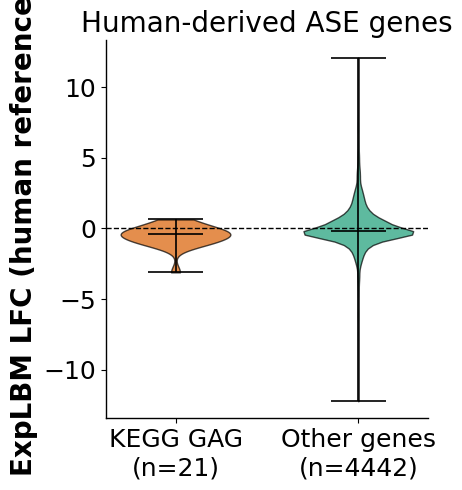

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 5))

data = [kegg_vals.dropna().values, non_kegg_vals.dropna().values]
positions = [1, 2]

vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.6,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

# style the violin bodies
colors = ["#d95f02", "#1b9e77"]
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.7)
    body.set_edgecolor("black")
    body.set_linewidth(1)

# style the median/extrema lines
for k in ["cmedians", "cbars", "cmins", "cmaxes"]:
    if k in vp:
        vp[k].set_color("black")
        vp[k].set_linewidth(1.2)

# x tick labels
ax.set_xticks(positions)
ax.set_xticklabels([
    f"KEGG GAG\n(n={len(kegg_vals)})",
    f"Other genes\n(n={len(non_kegg_vals)})"
])

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.set_ylabel("ExpLBM LFC (human reference)")
ax.set_title("Human-derived ASE genes")

plt.tight_layout()
plt.show()


In [66]:
hybrid_data_gags['ASE_full'].unique()

array(['ASE_human-derived', 'ASE_chimp-derived', 'nonASE_human-derived',
       nan, 'else_human-derived', 'nonASE_chimp-derived',
       'else_chimp-derived'], dtype=object)

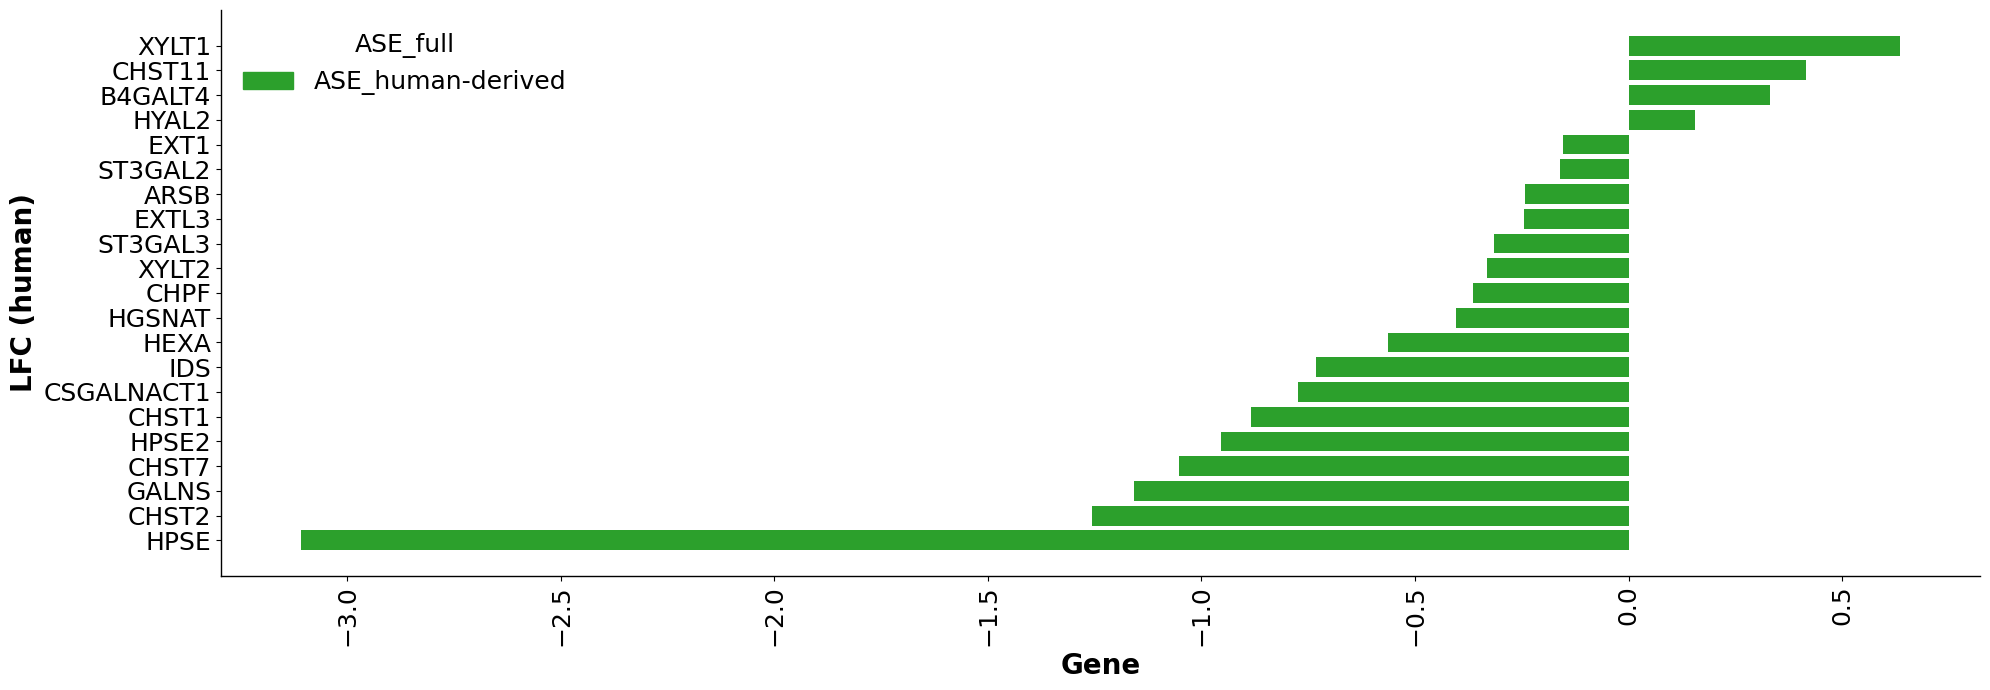

In [97]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# df = your dataframe
plot_df = hybrid_data_gags.copy()
plot_df = plot_df[plot_df["ASE_full"]=='ASE_human-derived']
# sort BEFORE plotting
plot_df = plot_df.sort_values("ExpLBM_LFC_human_ref", ascending=True)

# color mapping
color_map = {
    "ASE_chimp-derived": "tab:purple",
    "ASE_human-derived": "tab:green",
    "nonASE_human-derived": "tab:red",
    "nonASE_chimp-derived": "tab:red",
}

# colors for bars
bar_colors = plot_df["ASE_full"].map(color_map).fillna("tab:gray")

fig, ax = plt.subplots(figsize=(20, 7))

ax.barh(
    plot_df["Gene"],
    plot_df["ExpLBM_LFC_human_ref"].values,
    color=bar_colors
)

# ---- legend (only categories present + includes Unknown if any) ----
present = [k for k in color_map.keys() if k in set(plot_df["ASE_full"].dropna())]
handles = [mpatches.Patch(color=color_map[k], label=k) for k in present]

if (bar_colors == "tab:gray").any():
    handles.append(mpatches.Patch(color="tab:gray", label="Unknown/other"))

ax.legend(handles=handles, title="ASE_full", frameon=False)

ax.set_xlabel("Gene")
ax.set_ylabel("LFC (human)")

ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


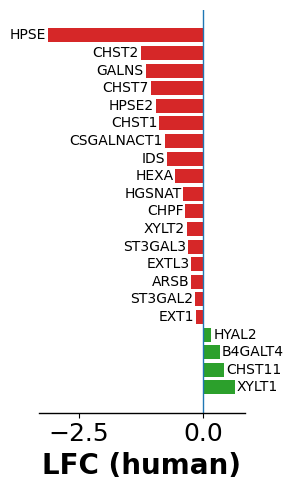

In [103]:
import numpy as np
import matplotlib.pyplot as plt

vals  = plot_df["ExpLBM_LFC_human_ref"].to_numpy()
genes = plot_df["Gene"].astype(str).to_numpy()
y = np.arange(len(plot_df))

# positives green, negatives red (NaNs -> gray)
bar_colors = np.where(np.isnan(vals), "tab:gray",
              np.where(vals >= 0, "tab:green", "tab:red"))

fig, ax = plt.subplots(figsize=(3, 5))

ax.barh(y, vals, color=bar_colors)

# vertical line at 0
ax.axvline(0, linewidth=1)

ax.set_xlabel("LFC (human)")

# remove y axis entirely (no spine, ticks, labels)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", left=False, right=False)

# gene labels right next to each bar end
xpad = 0.01 * (np.nanmax(vals) - np.nanmin(vals) + 1e-9)

for yi, v, g in zip(y, vals, genes):
    if np.isnan(v):
        continue
    if v >= 0:
        ax.text(v + xpad, yi, g, va="center", ha="left", clip_on=False)
    else:
        ax.text(v - xpad, yi, g, va="center", ha="right", clip_on=False)

# optional: first gene at top
ax.invert_yaxis()

const.save_fig(plt, 'hybrids_gags_ase_up_vs_down', output_path)


plt.tight_layout()
plt.show()


# HH 

In [22]:
#pathway_id = "hsa04020" # calcium signaling
#pathway_id = 'hsa04080' #Neuroactive ligand-receptor interaction
pathway_id = "hsa04340" #Hedgehog signaling pathway - Homo sapiens (human)
res = k.get(pathway_id)

# Parse the "GENE" section to get mapping; bioservices has a helper:
parsed = k.parse(res)
gene_entries = parsed["GENE"]
kegg_hh_genes = [v.split(";")[0].strip() for v in gene_entries.values()]

print(kegg_hh_genes)
print(len(kegg_hh_genes), "unique genes")

['TPTEP2-CSNK1E', 'KIF3A', 'CSNK1A1L', 'EVC2', 'CSNK1A1', 'CSNK1D', 'CSNK1E', 'CSNK1G2', 'CSNK1G3', 'GRK2', 'GRK3', 'MEGF8', 'EVC', 'IQCE', 'FBXW11', 'MGRN1', 'GPR161', 'GAS1', 'GLI1', 'GLI2', 'GLI3', 'GSK3B', 'SPOPL', 'IHH', 'KIF7', 'LRP2', 'ARRB1', 'ARRB2', 'DHH', 'CDON', 'SUFU', 'CSNK1G1', 'PRKACA', 'PRKACB', 'PRKACG', 'HHAT', 'SMURF1', 'PTCH1', 'HHATL', 'SCUBE2', 'CCND1', 'BCL2', 'HHIP', 'SHH', 'SMURF2', 'SMO', 'MOSMO', 'SPOP', 'EFCAB7', 'CUL3', 'CUL1', 'DISP1', 'PTCH2', 'CCND2', 'BTRC', 'BOC']
56 unique genes


In [23]:
hybrid_data_hh = hybrid_data[hybrid_data['Gene'].isin(kegg_hh_genes)]
hybrid_data_hh.to_csv("hybrid_data_hh.csv", index=False)


In [145]:
hybrid_data_hh = hybrid_data[hybrid_data['Gene'].isin(kegg_hh_genes)]
hybrid_data_hh['ASE_full'] = hybrid_data_hh['ExpLBM_gene_ase_type']+'_'+hybrid_data_hh['derived']

/tmp/ipykernel_2345654/2749118927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hybrid_data_hh['ASE_full'] = hybrid_data_hh['ExpLBM_gene_ase_type']+'_'+hybrid_data_hh['derived']


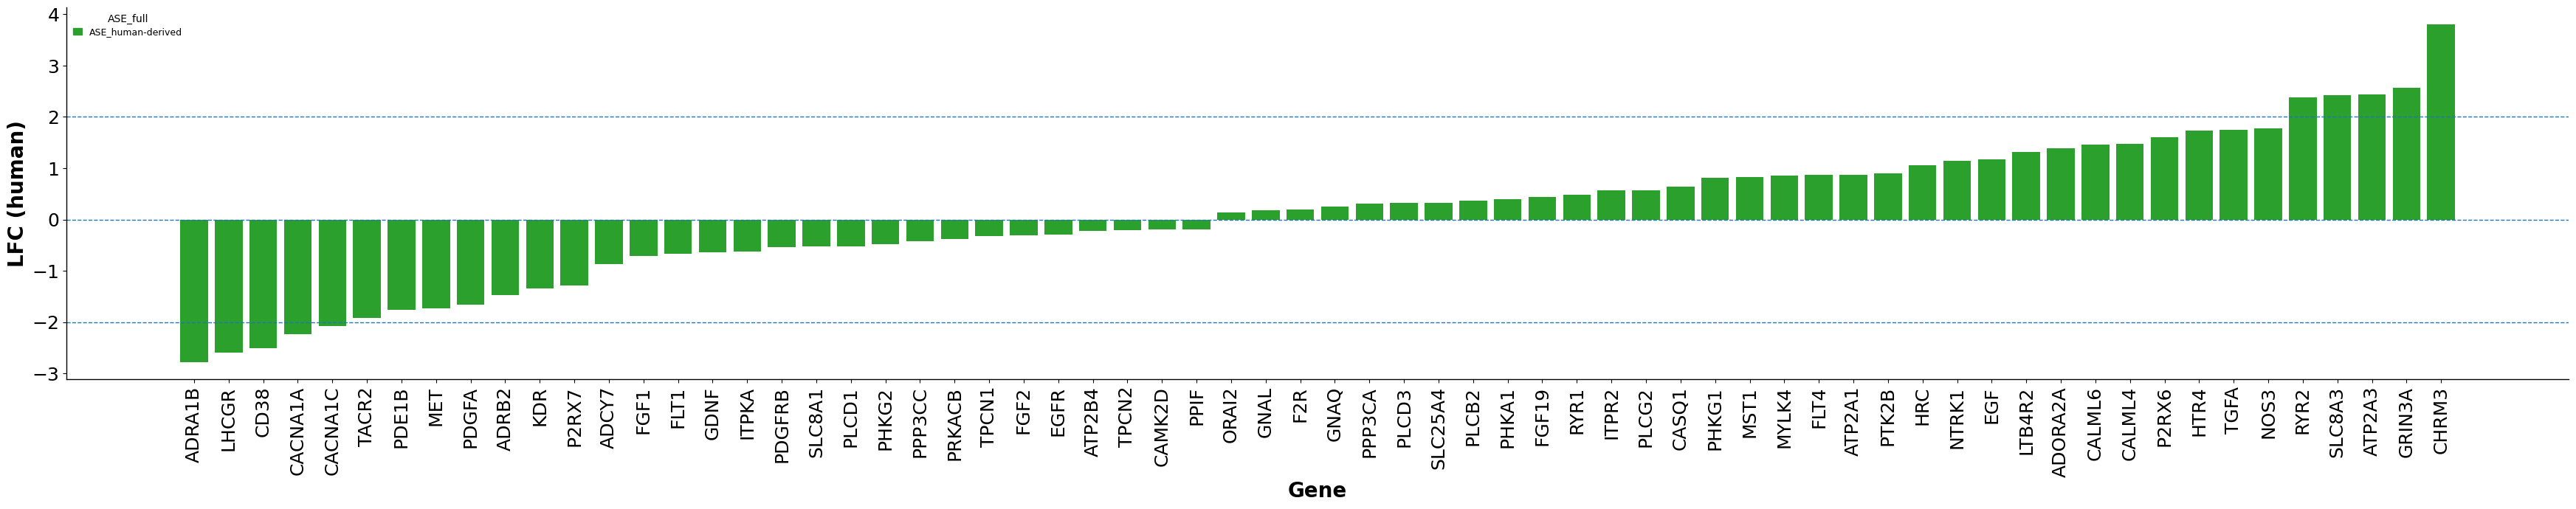

In [147]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# df = your dataframe
plot_df = hybrid_data_hh.copy()

# sort BEFORE plotting
plot_df = plot_df.sort_values("ExpLBM_LFC_human_ref", ascending=True)
plot_df = plot_df[plot_df['ASE_full']=="ASE_human-derived"]
# color mapping
color_map = {
    "ASE_chimp-derived": "tab:purple",
    "ASE_human-derived": "tab:green",
    "nonASE_human-derived": "tab:red",
    "nonASE_chimp-derived": "tab:red",
}

# colors for bars
bar_colors = plot_df["ASE_full"].map(color_map).fillna("tab:gray")

fig, ax = plt.subplots(figsize=(35, 7))

ax.bar(
    plot_df["Gene"],
    plot_df["ExpLBM_LFC_human_ref"].values,
    color=bar_colors
)

# ---- legend (only categories present + includes Unknown if any) ----
present = [k for k in color_map.keys() if k in set(plot_df["ASE_full"].dropna())]
handles = [mpatches.Patch(color=color_map[k], label=k) for k in present]

if (bar_colors == "tab:gray").any():
    handles.append(mpatches.Patch(color="tab:gray", label="Unknown/other"))

ax.legend(
    handles=handles,
    title="ASE_full",
    frameon=False,
    fontsize=9,          # smaller labels
    title_fontsize=10,   # smaller title
    handlelength=1.0,    # shorter color boxes
    handleheight=0.8,    # thinner color boxes
    labelspacing=0.3,    # tighter vertical spacing
    borderpad=0.2        # tighter padding
)
ax.set_xlabel("Gene")
ax.set_ylabel("LFC (human)")
for y in [-2,0,2]:
    ax.axhline(y=y, linestyle='--', linewidth=1)
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


# Check if the trans enviornment is the same for human and chimp

In [18]:
JASPAR_dataset = pd.read_csv(f'/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Sequence/Motifs_and_TFBS/JASPAR2024/JASPAR2024_CORE_vertebrates_non-redundant_meta.tsv', 
                     sep = '\t',
                       #usecols=range(0, 34), 
                     header=0)
JASPAR_TFs = (
  JASPAR_dataset["TF"]
  .dropna()
  .astype(str)
  .str.upper()
  .str.split(r"::|-", regex=True)  # split on both "::" and "-"
  .explode()
  .str.strip()
  .replace("", np.nan)
  .dropna()
  .unique()
)

hybrid_data_TFs = hybrid_data[hybrid_data['Gene'].isin(JASPAR_TFs)]

In [30]:
# Exclude "else" and missing categories, then compute ASE percentage
tmp = hybrid_data_TFs.loc[
    hybrid_data_TFs["ExpLBM_gene_ase_type"].notna()
    & (hybrid_data_TFs["ExpLBM_gene_ase_type"] != "else"),
    "ExpLBM_gene_ase_type"
]

ase_pct = (tmp.eq("ASE").mean()) * 100

print(f"ASE percentage (excluding 'else'): {ase_pct:.2f}%")
print(tmp.value_counts())


# Exclude "else" and missing categories, then compute ASE percentage for all hybrids
tmp_all = hybrid_data.loc[
    hybrid_data["ExpLBM_gene_ase_type"].notna()
    & (hybrid_data["ExpLBM_gene_ase_type"] != "else"),
    "ExpLBM_gene_ase_type"
]

ase_pct_all = tmp_all.eq("ASE").mean() * 100

print(f"ASE percentage in all hybrids (excluding 'else'): {ase_pct_all:.2f}%")
print(tmp_all.value_counts())

ASE percentage (excluding 'else'): 50.37%
ExpLBM_gene_ase_type
ASE       275
nonASE    271
Name: count, dtype: int64
ASE percentage in all hybrids (excluding 'else'): 57.42%
ExpLBM_gene_ase_type
ASE       9267
nonASE    6873
Name: count, dtype: int64


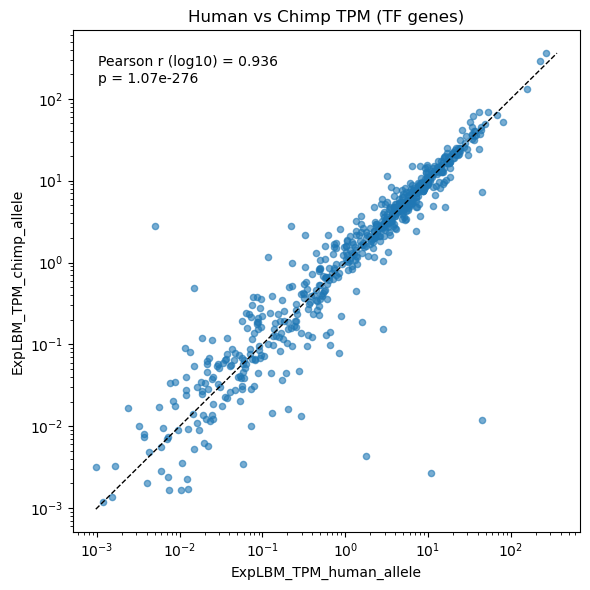

In [29]:
plot_df = hybrid_data_TFs.dropna(
    subset=["ExpLBM_TPM_human_allele", "ExpLBM_TPM_chimp_allele"]
).copy()

# log transform requires positive values
plot_df = plot_df[
    (plot_df["ExpLBM_TPM_human_allele"] > 0) &
    (plot_df["ExpLBM_TPM_chimp_allele"] > 0)
]

x = plot_df["ExpLBM_TPM_human_allele"]
y = plot_df["ExpLBM_TPM_chimp_allele"]

# Pearson on log-transformed values
log_x = np.log10(x)
log_y = np.log10(y)
r, p = pearsonr(log_x, log_y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=20, alpha=0.6)

line_min = min(x.min(), y.min())
line_max = max(x.max(), y.max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", linewidth=1, color="black")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ExpLBM_TPM_human_allele")
ax.set_ylabel("ExpLBM_TPM_chimp_allele")
ax.set_title("Human vs Chimp TPM (TF genes)")

ax.text(
    0.05, 0.95,
    f"Pearson r (log10) = {r:.3f}\np = {p:.2e}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.show()

## Compare osteoblat expression between human and chimp

In [36]:
osteoblasts_DE = pd.read_excel("/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Bone/Human/RNA-seq/In_vitro_osteogenic_cells_DE_housman.xlsx")

In [38]:
osteoblasts_DE['cell.subset'].unique()

array(['Time 0', 'Time 1', 'Time 2', 'iPSC.c1', 'iPSC.c2', 'MSC.c1',
       'Osteogenic.c1', 'Osteogenic.c2', 'iPSC', 'MSC', 'Osteogenic',
       'preosteoblast', 'osteoblast', 'embedding osteoblast',
       'mineralizing osteoblast', 'maturing osteocyte', 'Osteogenic.c3',
       'Osteogenic.c4'], dtype=object)

In [42]:
osteoblasts_DE_relevant = osteoblasts_DE[
    osteoblasts_DE["cell.subset"].isin(['Osteogenic.c1', 'Osteogenic.c2', 'iPSC', 'MSC', 'Osteogenic',
       'preosteoblast', 'osteoblast', 'embedding osteoblast',
       'mineralizing osteoblast', 'maturing osteocyte', 'Osteogenic.c3',
       'Osteogenic.c4'])]

In [47]:
osteoblasts_DE_relevant_TFs = osteoblasts_DE_relevant[osteoblasts_DE_relevant['Gene'].isin(JASPAR_TFs)]